# Regression Dataset EDA



In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.features.regression_dataset import build_regression_training_dataframe


In [3]:
df=build_regression_training_dataframe()

In [4]:
df.shape

(1959225, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1959225 entries, 0 to 1959224
Data columns (total 10 columns):
 #   Column                Dtype              
---  ------                -----              
 0   station_id            object             
 1   hour_timestamp        datetime64[ns, UTC]
 2   free_bikes_current    int64              
 3   empty_slots_current   int64              
 4   latitude              float64            
 5   longitude             float64            
 6   hour_of_day           int64              
 7   day_of_week           int64              
 8   is_weekend            bool               
 9   free_bikes_next_hour  int64              
dtypes: bool(1), datetime64[ns, UTC](1), float64(2), int64(5), object(1)
memory usage: 136.4+ MB


In [6]:
df["hour_timestamp"].min(), df["hour_timestamp"].max()


(Timestamp('2026-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2026-05-08 11:00:00+0000', tz='UTC'))

In [7]:
df["station_id"].nunique(), df["hour_timestamp"].nunique()


(1516, 1780)

In [8]:
all_days = pd.date_range(
    start=df["hour_timestamp"].min().floor("D"),
    end=df["hour_timestamp"].max().floor("D"),
    freq="D",
    tz="UTC",
)

observed_days = (
    df["hour_timestamp"]
    .dt.floor("D")
    .drop_duplicates()
    .sort_values()
)

missing_days = all_days.difference(observed_days)

missing_days


DatetimeIndex(['2026-03-16 00:00:00+00:00', '2026-03-17 00:00:00+00:00',
               '2026-03-18 00:00:00+00:00', '2026-03-19 00:00:00+00:00',
               '2026-03-20 00:00:00+00:00', '2026-03-21 00:00:00+00:00',
               '2026-03-22 00:00:00+00:00', '2026-03-23 00:00:00+00:00',
               '2026-03-24 00:00:00+00:00', '2026-03-25 00:00:00+00:00',
               '2026-03-26 00:00:00+00:00', '2026-03-27 00:00:00+00:00',
               '2026-03-28 00:00:00+00:00', '2026-03-29 00:00:00+00:00',
               '2026-03-30 00:00:00+00:00', '2026-03-31 00:00:00+00:00',
               '2026-04-01 00:00:00+00:00', '2026-04-02 00:00:00+00:00',
               '2026-04-03 00:00:00+00:00', '2026-04-04 00:00:00+00:00',
               '2026-04-05 00:00:00+00:00', '2026-04-06 00:00:00+00:00',
               '2026-04-07 00:00:00+00:00', '2026-04-08 00:00:00+00:00',
               '2026-04-09 00:00:00+00:00', '2026-04-10 00:00:00+00:00',
               '2026-04-11 00:00:00+00:00', '2026-0

In [9]:
len(missing_days)


47

In [10]:
daily_counts = (
    df["hour_timestamp"]
    .dt.floor("D")
    .value_counts()
    .sort_index()
)

daily_counts


hour_timestamp
2026-01-01 00:00:00+00:00    20846
2026-01-02 00:00:00+00:00    23121
2026-01-03 00:00:00+00:00    22860
2026-01-04 00:00:00+00:00    22525
2026-01-05 00:00:00+00:00    21811
                             ...  
2026-05-03 00:00:00+00:00     3016
2026-05-04 00:00:00+00:00     3016
2026-05-05 00:00:00+00:00     1508
2026-05-06 00:00:00+00:00     1508
2026-05-08 00:00:00+00:00     1508
Name: count, Length: 81, dtype: int64

In [11]:
hourly_counts = df["hour_of_day"].value_counts().sort_index()
hourly_counts


hour_of_day
0      59672
1      45217
2      35618
3      34822
4      41870
5      59885
6      84214
7      94060
8      93230
9      92854
10     95534
11    100619
12    100256
13     96859
14     96798
15     99028
16    109038
17    104768
18    100270
19     93749
20     89440
21     85596
22     77608
23     68220
Name: count, dtype: int64

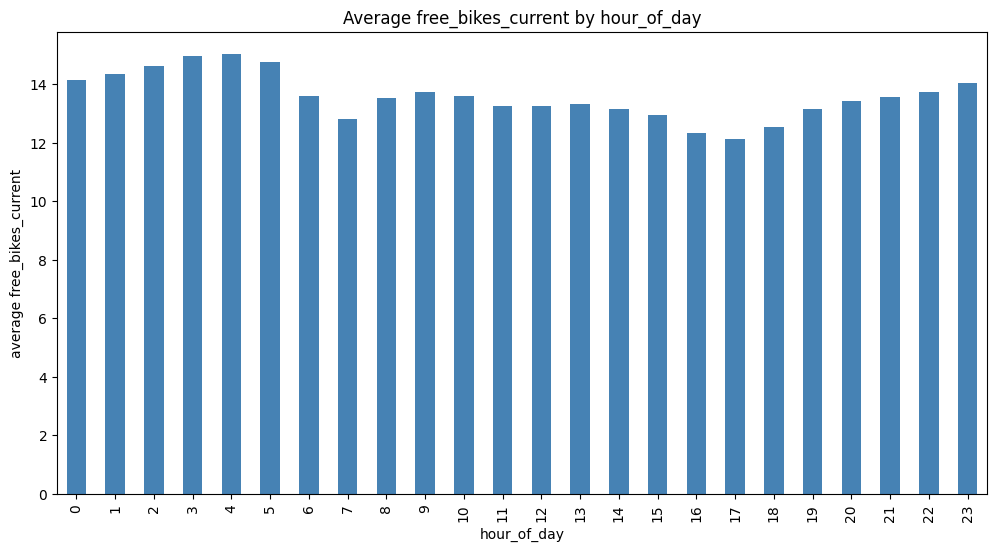

In [12]:
df.groupby("hour_of_day")["free_bikes_current"].mean().plot(
    kind="bar",
    figsize=(12, 6),
    color="steelblue"
)

plt.title("Average free_bikes_current by hour_of_day")
plt.xlabel("hour_of_day")
plt.ylabel("average free_bikes_current")
plt.show()


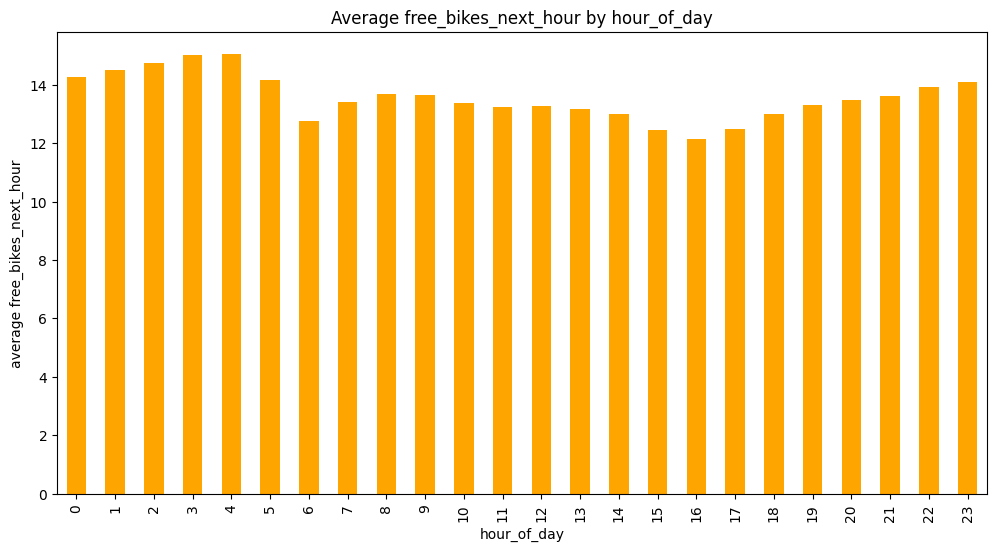

In [13]:
df.groupby("hour_of_day")["free_bikes_next_hour"].mean().plot(
    kind="bar",
    figsize=(12, 6),
    color="orange"
)

plt.title("Average free_bikes_next_hour by hour_of_day")
plt.xlabel("hour_of_day")
plt.ylabel("average free_bikes_next_hour")
plt.show()


In [14]:
df.groupby("hour_of_day")["free_bikes_current"].mean()


hour_of_day
0     14.127346
1     14.338523
2     14.636841
3     14.968267
4     15.036972
5     14.742456
6     13.590531
7     12.801744
8     13.524928
9     13.720744
10    13.584357
11    13.268399
12    13.259835
13    13.323357
14    13.147699
15    12.932867
16    12.333159
17    12.118299
18    12.546494
19    13.151287
20    13.435163
21    13.556042
22    13.739344
23    14.023952
Name: free_bikes_current, dtype: float64

In [15]:
df.groupby("hour_of_day")["free_bikes_next_hour"].mean()


hour_of_day
0     14.272138
1     14.490568
2     14.745690
3     15.025559
4     15.052950
5     14.156817
6     12.755884
7     13.391452
8     13.662887
9     13.644248
10    13.357422
11    13.247587
12    13.278707
13    13.170681
14    12.988450
15    12.455083
16    12.135788
17    12.479144
18    13.005595
19    13.298638
20    13.464490
21    13.623989
22    13.904572
23    14.087027
Name: free_bikes_next_hour, dtype: float64

free_bikes_current and free_bikes_next_hour show a similar hourly pattern, with lower availability during daytime and late afternoon, suggesting meaningful temporal structure in the prediction problem.


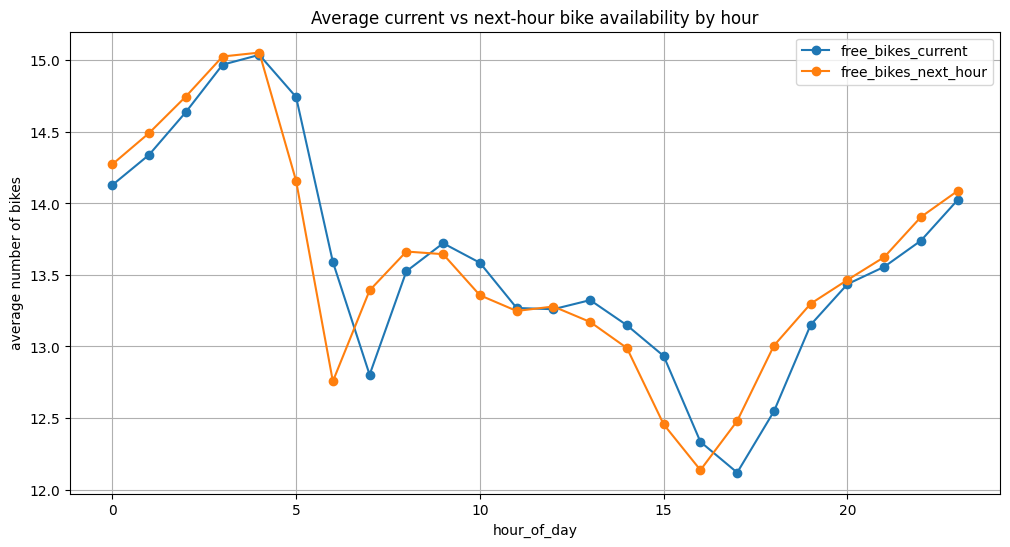

In [16]:
hourly_means = df.groupby("hour_of_day")[["free_bikes_current", "free_bikes_next_hour"]].mean()

hourly_means.plot(figsize=(12, 6), marker="o")
plt.title("Average current vs next-hour bike availability by hour")
plt.xlabel("hour_of_day")
plt.ylabel("average number of bikes")
plt.grid(True)
plt.show()


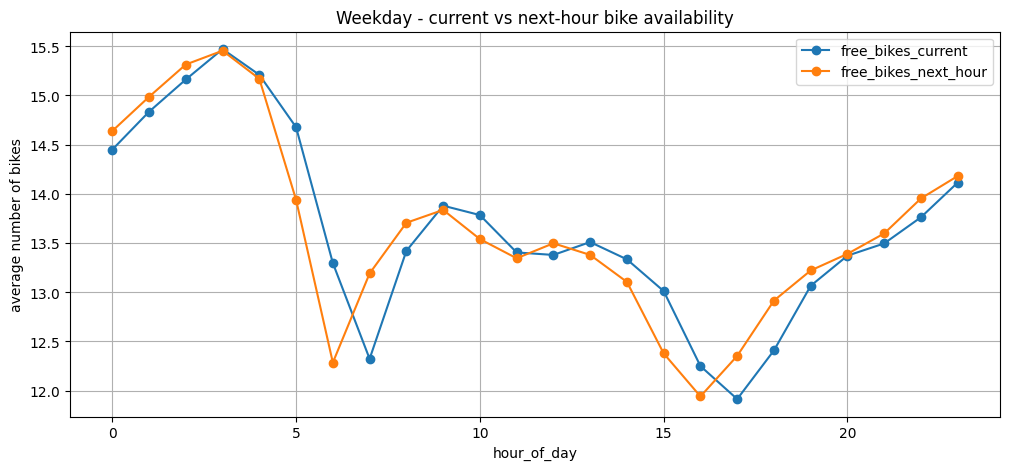

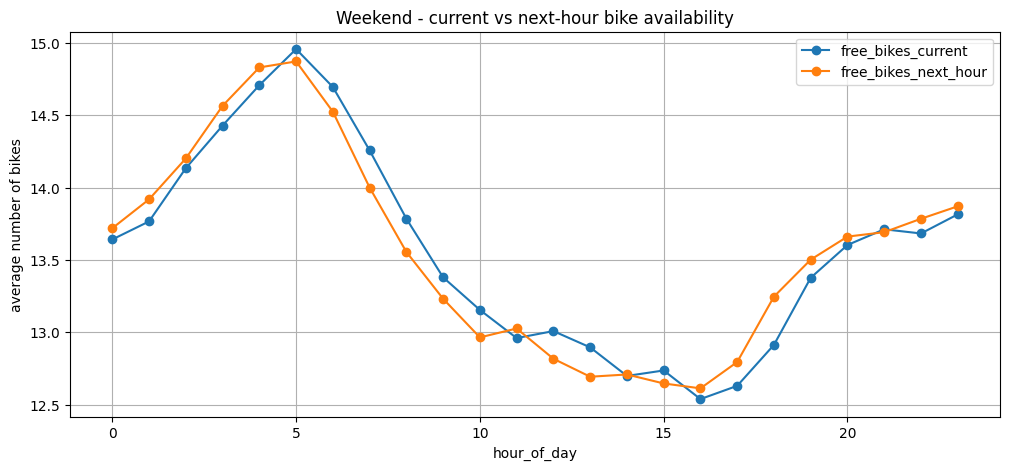

In [17]:
weekend_hourly_means = (
    df.groupby(["is_weekend", "hour_of_day"])[["free_bikes_current", "free_bikes_next_hour"]]
    .mean()
    .reset_index()
)

for is_weekend, subset in weekend_hourly_means.groupby("is_weekend"):
    label = "Weekend" if is_weekend else "Weekday"
    plt.figure(figsize=(12, 5))
    plt.plot(subset["hour_of_day"], subset["free_bikes_current"], marker="o", label="free_bikes_current")
    plt.plot(subset["hour_of_day"], subset["free_bikes_next_hour"], marker="o", label="free_bikes_next_hour")
    plt.title(f"{label} - current vs next-hour bike availability")
    plt.xlabel("hour_of_day")
    plt.ylabel("average number of bikes")
    plt.grid(True)
    plt.legend()
    plt.show()


the curve is smoother in the weekends 

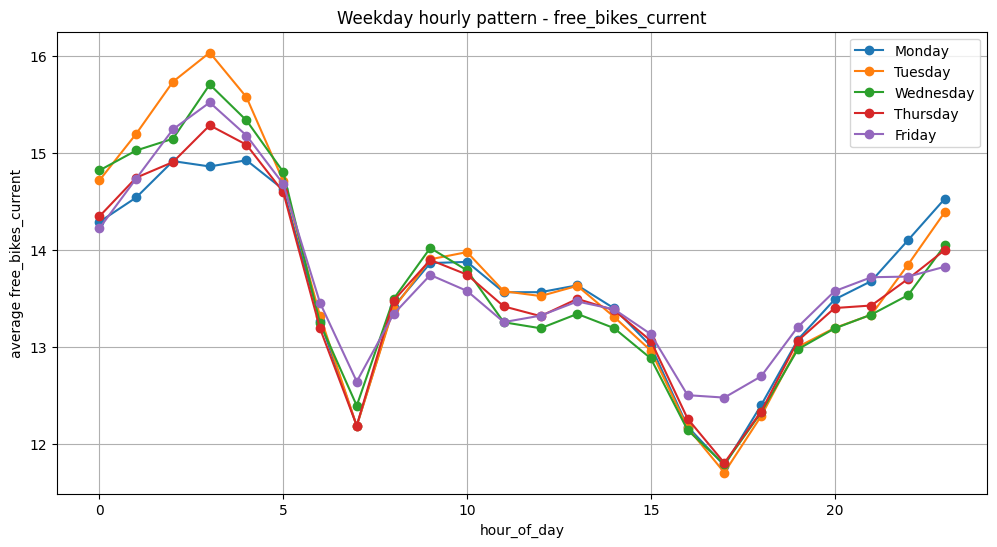

In [18]:
hourly_by_day = (
    df.groupby(["day_of_week", "hour_of_day"])["free_bikes_current"]
    .mean()
    .reset_index()
)

day_labels = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
}

plt.figure(figsize=(12, 6))

for day in [1, 2, 3, 4, 5]:
    subset = hourly_by_day[hourly_by_day["day_of_week"] == day]
    plt.plot(
        subset["hour_of_day"],
        subset["free_bikes_current"],
        marker="o",
        label=day_labels[day]
    )

plt.title("Weekday hourly pattern - free_bikes_current")
plt.xlabel("hour_of_day")
plt.ylabel("average free_bikes_current")
plt.grid(True)
plt.legend()
plt.show()


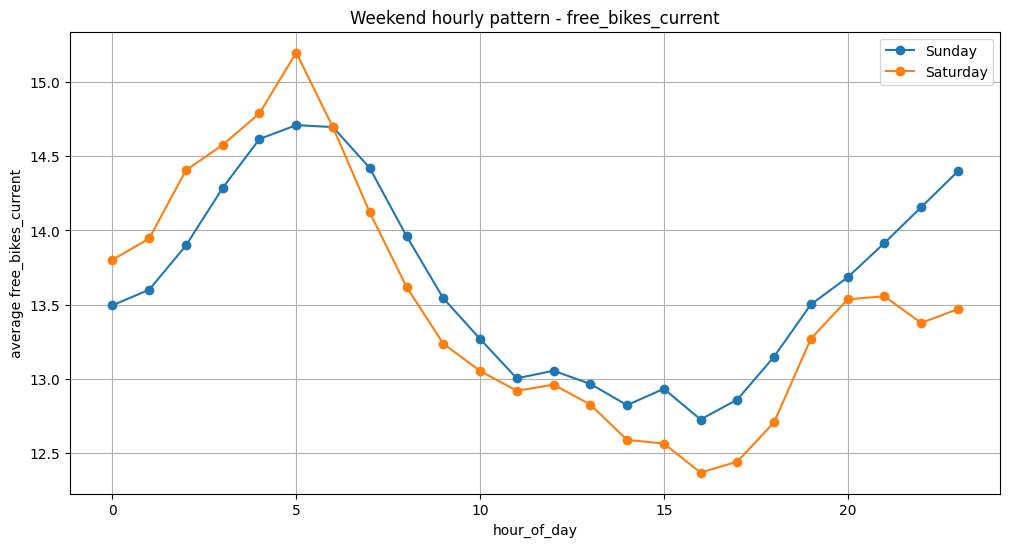

In [19]:
plt.figure(figsize=(12, 6))

for day in [0, 6]:
    subset = hourly_by_day[hourly_by_day["day_of_week"] == day]
    plt.plot(
        subset["hour_of_day"],
        subset["free_bikes_current"],
        marker="o",
        label=day_labels[day]
    )

plt.title("Weekend hourly pattern - free_bikes_current")
plt.xlabel("hour_of_day")
plt.ylabel("average free_bikes_current")
plt.grid(True)
plt.legend()
plt.show()


we can see that there's the same patterns no matter the day of the week so it's maybe a feature we can potentially delete 

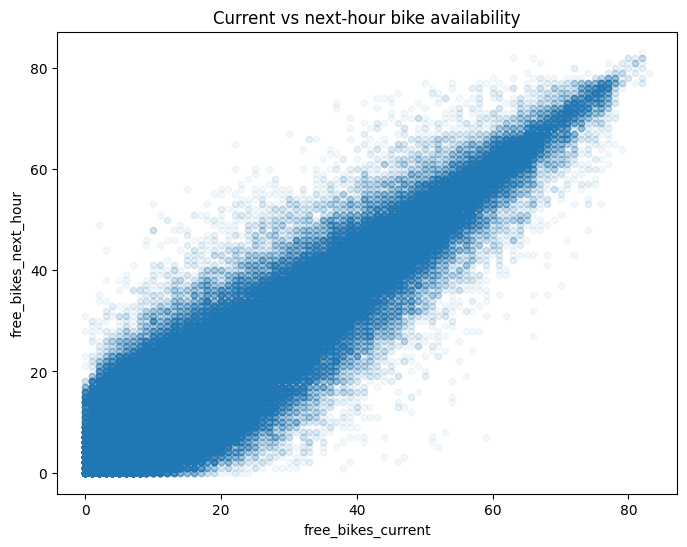

In [20]:
df.plot(
    kind="scatter",
    x="free_bikes_current",
    y="free_bikes_next_hour",
    figsize=(8, 6),
    alpha=0.05
)

plt.title("Current vs next-hour bike availability")
plt.xlabel("free_bikes_current")
plt.ylabel("free_bikes_next_hour")
plt.show()


In [21]:
df[["free_bikes_current", "free_bikes_next_hour"]].corr()


,free_bikes_current,free_bikes_next_hour
free_bikes_current,1.000000,0.964666
free_bikes_next_hour,0.964666,1.000000


In [22]:
station_counts = df["station_id"].value_counts()
station_counts.describe()


count    1516.000000
mean     1292.364776
std       342.417998
min         1.000000
25%      1206.750000
50%      1400.000000
75%      1513.250000
max      1742.000000
Name: count, dtype: float64

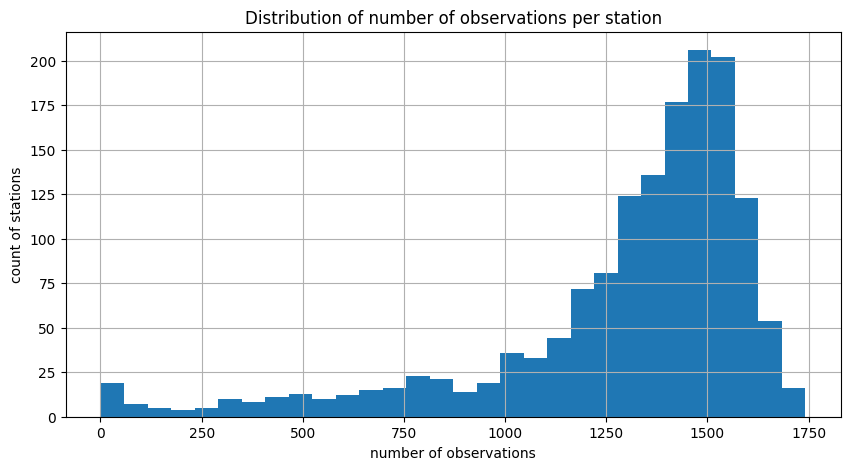

In [23]:
station_counts.hist(bins=30, figsize=(10, 5))
plt.title("Distribution of number of observations per station")
plt.xlabel("number of observations")
plt.ylabel("count of stations")
plt.show()


The station-level coverage is uneven: although most stations have a relatively high number of observations, a small subset is severely underrepresented.

In [24]:
station_mean_bikes = df.groupby("station_id")["free_bikes_current"].mean()
station_mean_bikes.describe()


count    1516.000000
mean       12.889838
std         8.724047
min         0.000000
25%         6.481690
50%        10.462114
75%        16.589462
max        61.990323
Name: free_bikes_current, dtype: float64

Average bike availability varies substantially across stations, with a right-skewed distribution and a small number of stations showing much higher average availability than the typical station.

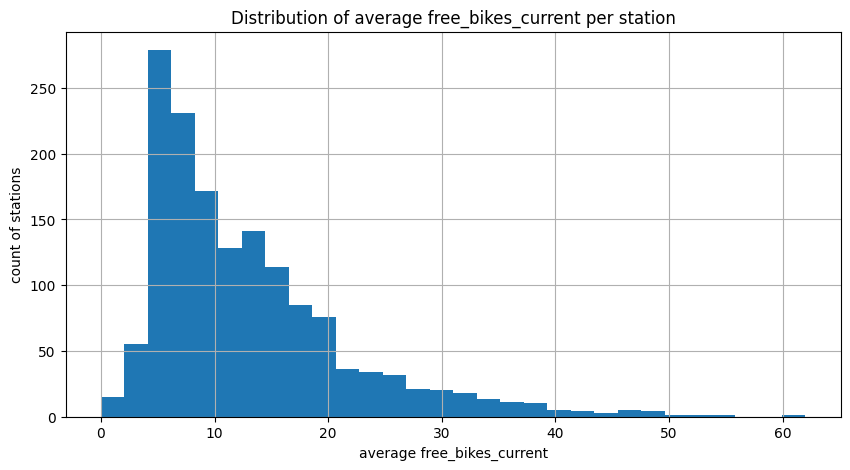

In [25]:
station_mean_bikes.hist(bins=30, figsize=(10, 5))
plt.title("Distribution of average free_bikes_current per station")
plt.xlabel("average free_bikes_current")
plt.ylabel("count of stations")
plt.show()


In [26]:
station_capacity = (
    df.assign(capacity=df["free_bikes_current"] + df["empty_slots_current"])
      .groupby("station_id")["capacity"]
      .max()
)

station_capacity.describe()
 

count    1516.000000
mean       32.538918
std        13.255815
min         0.000000
25%        23.000000
50%        30.000000
75%        39.000000
max       200.000000
Name: capacity, dtype: float64

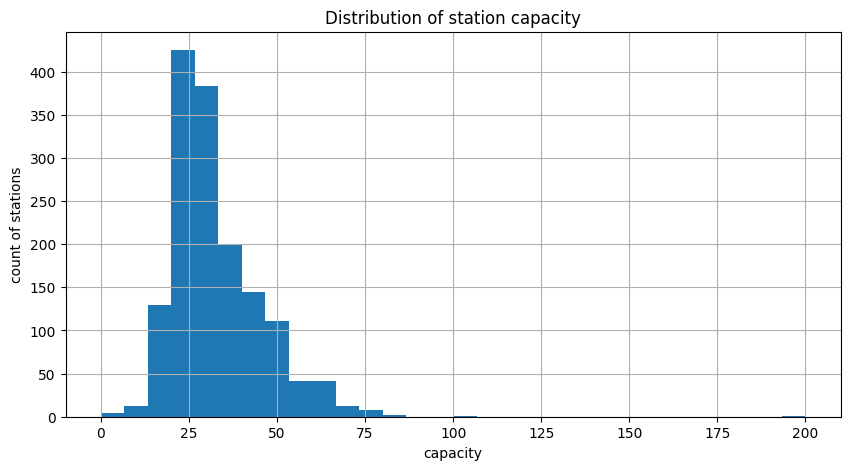

In [27]:
station_capacity.hist(bins=30, figsize=(10, 5))
plt.title("Distribution of station capacity")
plt.xlabel("capacity")
plt.ylabel("count of stations")
plt.show()


Station capacity is strongly heterogeneous and right-skewed, suggesting that raw bike counts should be interpreted in the context of station size.

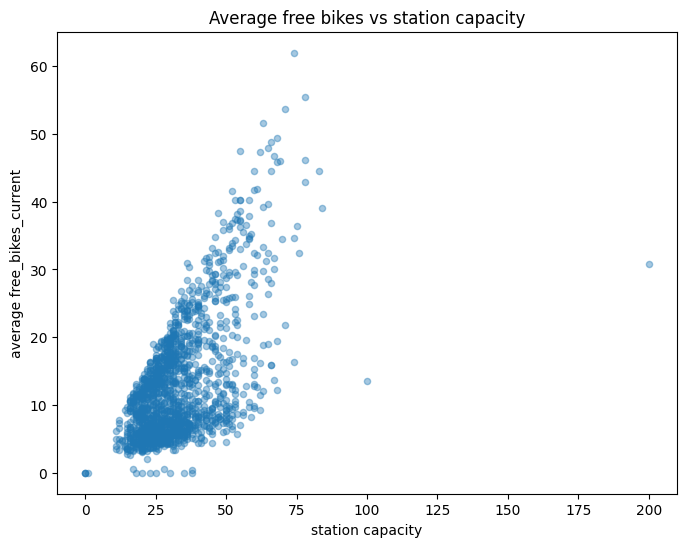

In [28]:
station_summary = (
    df.assign(capacity=df["free_bikes_current"] + df["empty_slots_current"])
      .groupby("station_id")
      .agg(
          avg_free_bikes=("free_bikes_current", "mean"),
          capacity=("capacity", "max"),
      )
)

station_summary.plot(
    kind="scatter",
    x="capacity",
    y="avg_free_bikes",
    figsize=(8, 6),
    alpha=0.4
)

plt.title("Average free bikes vs station capacity")
plt.xlabel("station capacity")
plt.ylabel("average free_bikes_current")
plt.show()


In [29]:
station_summary[["capacity", "avg_free_bikes"]].corr()


,capacity,avg_free_bikes
capacity,1.000000,0.610094
avg_free_bikes,0.610094,1.000000


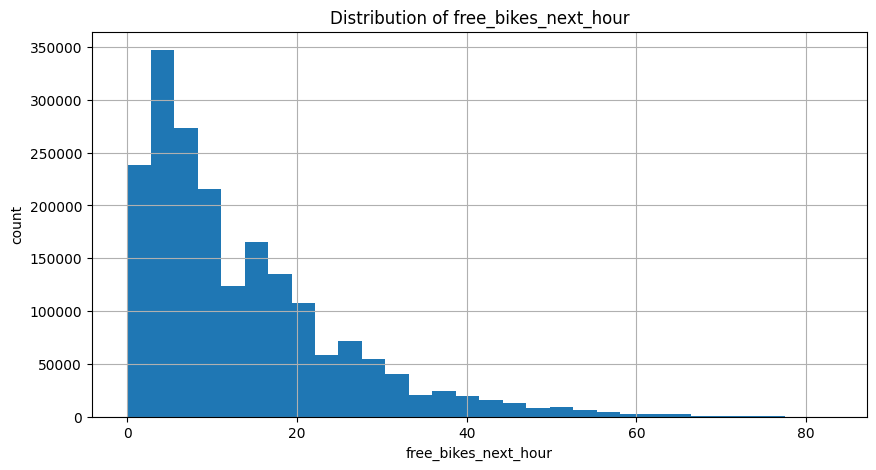

In [30]:
df["free_bikes_next_hour"].hist(bins=30, figsize=(10, 5))
plt.title("Distribution of free_bikes_next_hour")
plt.xlabel("free_bikes_next_hour")
plt.ylabel("count")
plt.show()


In [31]:
df.groupby("hour_of_day")["free_bikes_next_hour"].mean()


hour_of_day
0     14.272138
1     14.490568
2     14.745690
3     15.025559
4     15.052950
5     14.156817
6     12.755884
7     13.391452
8     13.662887
9     13.644248
10    13.357422
11    13.247587
12    13.278707
13    13.170681
14    12.988450
15    12.455083
16    12.135788
17    12.479144
18    13.005595
19    13.298638
20    13.464490
21    13.623989
22    13.904572
23    14.087027
Name: free_bikes_next_hour, dtype: float64

let's see how to do things for a few individual stations 

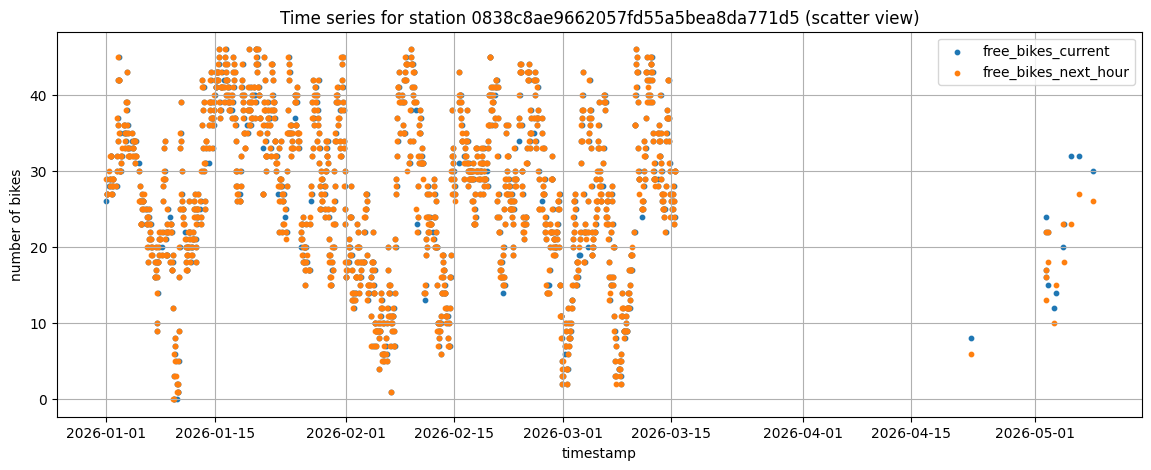

In [32]:
sample_stations = df["station_id"].drop_duplicates().sample(3, random_state=42)

sample_stations



station_id = sample_stations.iloc[0]

station_df = (
    df[df["station_id"] == station_id]
    .sort_values("hour_timestamp")
)
plt.figure(figsize=(14, 5))
plt.scatter(station_df["hour_timestamp"], station_df["free_bikes_current"], s=10, label="free_bikes_current")
plt.scatter(station_df["hour_timestamp"], station_df["free_bikes_next_hour"], s=10, label="free_bikes_next_hour")
plt.title(f"Time series for station {station_id} (scatter view)")
plt.xlabel("timestamp")
plt.ylabel("number of bikes")
plt.legend()
plt.grid(True)
plt.show()



At the individual-station level, the series are not temporally continuous across the full global date range; instead, they consist of dense local windows and sparse later observations, which confirms the irregular temporal coverage previously identified at the dataset level.

In [36]:
continuous_df = df[
    (df["hour_timestamp"] >= "2026-01-01")
    & (df["hour_timestamp"] < "2026-03-16")
].copy()

continuous_df.shape


(1938113, 10)

In [37]:
continuous_days = (
    continuous_df["hour_timestamp"]
    .dt.floor("D")
    .drop_duplicates()
    .sort_values()
)

continuous_days


0      2026-01-01 00:00:00+00:00
11     2026-01-02 00:00:00+00:00
23     2026-01-03 00:00:00+00:00
35     2026-01-04 00:00:00+00:00
45     2026-01-05 00:00:00+00:00
                  ...           
1189   2026-03-11 00:00:00+00:00
1206   2026-03-12 00:00:00+00:00
1225   2026-03-13 00:00:00+00:00
1241   2026-03-14 00:00:00+00:00
1259   2026-03-15 00:00:00+00:00
Name: hour_timestamp, Length: 74, dtype: datetime64[ns, UTC]

In [38]:
continuous_df["station_id"].nunique(), continuous_df["hour_timestamp"].nunique()


(1513, 1766)

In [39]:
station_active_days_continuous = (
    continuous_df.assign(day=continuous_df["hour_timestamp"].dt.floor("D"))
    .groupby("station_id")["day"]
    .nunique()
)

station_active_days_continuous.describe()


count    1513.000000
mean       72.463979
std         8.843596
min         1.000000
25%        74.000000
50%        74.000000
75%        74.000000
max        74.000000
Name: day, dtype: float64

In [40]:
working_df = continuous_df.copy()
working_df.shape


(1938113, 10)

## Summary

- The full dataset is not temporally continuous, with many missing days between March 1 and May 6, 2026.
- Most of the useful data is concentrated in a dense and coherent block from March 1 to March 15, 2026.
- Keeping only this March block preserves most observations while greatly improving temporal consistency.
- The filtered subset still has strong coverage, with 1512 stations and 350 distinct hourly timestamps.
- Station-level continuity is also strong in this subset, since most stations are observed on all 15 days.
- Bike availability shows a clear hourly pattern, with lower values during daytime and late afternoon.
- Weekend patterns are smoother than weekday patterns, which suggests that `is_weekend` is a meaningful feature.
- `day_of_week` appears to add limited signal beyond the broader weekday/weekend distinction.
- `free_bikes_current` is very strongly related to `free_bikes_next_hour`, confirming a strong autoregressive structure.
- Station-level average availability and station capacity are both highly heterogeneous and right-skewed.
- Capacity explains part of the cross-station variability, but not all of it.

## Decision

- Use the continuous March subset as the main working dataset.
- Start with `free_bikes_current`, `empty_slots_current`, `hour_of_day`, and `is_weekend` as core features.
- Treat `day_of_week` as optional and validate its usefulness later.


In [41]:
feature_columns = [
    "free_bikes_current",
    "empty_slots_current",
    "hour_of_day",
    "is_weekend",
]

target_column = "free_bikes_next_hour"

X = working_df[feature_columns]
y = working_df[target_column]

X.shape, y.shape


((1938113, 4), (1938113,))

In [42]:
train_end = pd.Timestamp("2026-03-11 00:00:00", tz="UTC")
val_end = pd.Timestamp("2026-03-13 00:00:00", tz="UTC")

train_df = working_df[working_df["hour_timestamp"] < train_end]
val_df = working_df[
    (working_df["hour_timestamp"] >= train_end)
    & (working_df["hour_timestamp"] < val_end)
]
test_df = working_df[working_df["hour_timestamp"] >= val_end]

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_val = val_df[feature_columns]
y_val = val_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]


In [43]:
print(train_df["hour_timestamp"].min(), train_df["hour_timestamp"].max())
print(val_df["hour_timestamp"].min(), val_df["hour_timestamp"].max())
print(test_df["hour_timestamp"].min(), test_df["hour_timestamp"].max())

print(X_train.shape, X_val.shape, X_test.shape)


2026-01-01 00:00:00+00:00 2026-03-10 23:00:00+00:00
2026-03-11 00:00:00+00:00 2026-03-12 23:00:00+00:00
2026-03-13 00:00:00+00:00 2026-03-15 13:00:00+00:00
(1816645, 4) (54395, 4) (67073, 4)


In [44]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri(f"file://{project_root / 'mlruns'}")

mlflow.set_experiment("velib-demand-forecasting")



/Users/zakariaouahabi/Documents/velib-demand-forecasting/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
Traceback (most recent call last):
  File "/Users/zakariaouahabi/Documents/velib-demand-forecasting/.venv/lib/python3.12/site-packages/mlflow/store/tracking/file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/zakariaouahabi/Documents/velib-demand-forecasting/.venv/lib/python3.12/site-packages/mlflow/store/tracking/file_store.py", line 481, in _get_experiment
    meta = FileStore._read

<Experiment: artifact_location='file:///Users/zakariaouahabi/Documents/velib-demand-forecasting/mlruns/816218909226413421', creation_time=1778422771964, experiment_id='816218909226413421', last_update_time=1778422771964, lifecycle_stage='active', name='velib-demand-forecasting', tags={}, trace_location=None, workspace='default'>

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_model = LinearRegression()

with mlflow.start_run(run_name="linear_regression_baseline"):
    baseline_model.fit(X_train, y_train)

    val_predictions = baseline_model.predict(X_val)

    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    mlflow.log_param("model_name", "LinearRegression")
    mlflow.log_param("features", feature_columns)

    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.sklearn.log_model(baseline_model, "model")

    print("Validation RMSE:", val_rmse)
    print("Validation MAE:", val_mae)
    print("Validation R2:", val_r2)


2026/05/15 16:31:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 16:31:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Validation RMSE: 3.3208844531555037
Validation MAE: 2.2645354048104585
Validation R2: 0.9140300830368377


In [46]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)

with mlflow.start_run(run_name="random_forest_baseline"):
    rf_model.fit(X_train, y_train)

    val_predictions = rf_model.predict(X_val)

    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    mlflow.log_param("model_name", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("features", feature_columns)

    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.sklearn.log_model(rf_model, "model")

    print("Validation RMSE:", val_rmse)
    print("Validation MAE:", val_mae)
    print("Validation R2:", val_r2)


2026/05/15 16:31:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 16:31:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Validation RMSE: 3.3206574541672564
Validation MAE: 2.2795684788613513
Validation R2: 0.9140418355789506


In [47]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42,
)

with mlflow.start_run(run_name="gradient_boosting_baseline"):
    gb_model.fit(X_train, y_train)

    val_predictions = gb_model.predict(X_val)

    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("features", feature_columns)

    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.sklearn.log_model(gb_model, "model")

    print("Validation RMSE:", val_rmse)
    print("Validation MAE:", val_mae)
    print("Validation R2:", val_r2)


2026/05/15 16:32:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 16:32:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Validation RMSE: 3.26709250642519
Validation MAE: 2.2316794577141255
Validation R2: 0.916792621354046


In [48]:
with mlflow.start_run(run_name="naive_baseline_current_equals_next"):
    val_predictions = X_val["free_bikes_current"]

    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    mlflow.log_param("model_name", "NaiveBaseline")
    mlflow.log_param("rule", "predict free_bikes_next_hour = free_bikes_current")
    mlflow.log_param("features", ["free_bikes_current"])

    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)

    print("Validation RMSE:", val_rmse)
    print("Validation MAE:", val_mae)
    print("Validation R2:", val_r2)


Validation RMSE: 3.360946994916479
Validation MAE: 2.2411986395808436
Validation R2: 0.911943320684309


The GradientBoostingRegressor achieves the best validation performance so far, but the naïve baseline remains highly competitive, confirming that the forecasting problem is strongly driven by the current bike availability level.

In [49]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)

with mlflow.start_run(run_name="gbr_tuned_1"):
    gb_model.fit(X_train, y_train)

    val_predictions = gb_model.predict(X_val)

    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("features", feature_columns)

    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.sklearn.log_model(gb_model, "model")

    print("Validation RMSE:", val_rmse)
    print("Validation MAE:", val_mae)
    print("Validation R2:", val_r2)


2026/05/15 16:34:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 16:34:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Validation RMSE: 3.2679866971219953
Validation MAE: 2.2315091863586187
Validation R2: 0.9167470680397836


In [50]:
from sklearn.model_selection import TimeSeriesSplit

dev_df = pd.concat([train_df, val_df]).sort_values("hour_timestamp").reset_index(drop=True)
X_dev = dev_df[feature_columns]
y_dev = dev_df[target_column]

tscv = TimeSeriesSplit(n_splits=3)


In [51]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


fold_rmse = []
fold_mae = []
fold_r2 = []

with mlflow.start_run(run_name="gbr_timeseries_cv"):
    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("cv_type", "TimeSeriesSplit")
    mlflow.log_param("n_splits", 3)
    mlflow.log_param("features", feature_columns)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):
        X_fold_train = X_dev.iloc[train_idx]
        y_fold_train = y_dev.iloc[train_idx]

        X_fold_val = X_dev.iloc[val_idx]
        y_fold_val = y_dev.iloc[val_idx]

        model = GradientBoostingRegressor(
            n_estimators=100,
            random_state=42,
        )

        model.fit(X_fold_train, y_fold_train)
        val_predictions = model.predict(X_fold_val)

        rmse = np.sqrt(mean_squared_error(y_fold_val, val_predictions))
        mae = mean_absolute_error(y_fold_val, val_predictions)
        r2 = r2_score(y_fold_val, val_predictions)

        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)

        mlflow.log_metric(f"fold_{fold}_rmse", rmse)
        mlflow.log_metric(f"fold_{fold}_mae", mae)
        mlflow.log_metric(f"fold_{fold}_r2", r2)

        print(f"Fold {fold} RMSE: {rmse:.4f}")
        print(f"Fold {fold} MAE: {mae:.4f}")
        print(f"Fold {fold} R2: {r2:.4f}")
        print()

    mlflow.log_metric("cv_rmse_mean", np.mean(fold_rmse))
    mlflow.log_metric("cv_mae_mean", np.mean(fold_mae))
    mlflow.log_metric("cv_r2_mean", np.mean(fold_r2))

    print("Mean CV RMSE:", np.mean(fold_rmse))
    print("Mean CV MAE:", np.mean(fold_mae))
    print("Mean CV R2:", np.mean(fold_r2))


Fold 1 RMSE: 3.0621
Fold 1 MAE: 2.0876
Fold 1 R2: 0.9314

Fold 2 RMSE: 2.9583
Fold 2 MAE: 2.0071
Fold 2 R2: 0.9351

Fold 3 RMSE: 3.2575
Fold 3 MAE: 2.1965
Fold 3 R2: 0.9217

Mean CV RMSE: 3.0926501399478217
Mean CV MAE: 2.0970840691660553
Mean CV R2: 0.9293801726687873


In [52]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

param_grid = [
    {
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 3,
        "min_samples_leaf": 1,
        "subsample": 1.0,
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 1,
        "subsample": 1.0,
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_samples_leaf": 1,
        "subsample": 1.0,
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 5,
        "subsample": 1.0,
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 5,
        "subsample": 0.8,
    },
]

cv_results = []

for run_idx, params in enumerate(param_grid, start=1):
    fold_rmse = []
    fold_mae = []
    fold_r2 = []

    with mlflow.start_run(run_name=f"gbr_cv_tuning_run_{run_idx}"):
        mlflow.log_param("model_name", "GradientBoostingRegressor")
        mlflow.log_param("cv_type", "TimeSeriesSplit")
        mlflow.log_param("n_splits", 3)
        mlflow.log_param("features", feature_columns)

        for key, value in params.items():
            mlflow.log_param(key, value)

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):
            X_fold_train = X_dev.iloc[train_idx]
            y_fold_train = y_dev.iloc[train_idx]

            X_fold_val = X_dev.iloc[val_idx]
            y_fold_val = y_dev.iloc[val_idx]

            model = GradientBoostingRegressor(
                n_estimators=params["n_estimators"],
                learning_rate=params["learning_rate"],
                max_depth=params["max_depth"],
                min_samples_leaf=params["min_samples_leaf"],
                subsample=params["subsample"],
                random_state=42,
            )

            model.fit(X_fold_train, y_fold_train)
            val_predictions = model.predict(X_fold_val)

            rmse = np.sqrt(mean_squared_error(y_fold_val, val_predictions))
            mae = mean_absolute_error(y_fold_val, val_predictions)
            r2 = r2_score(y_fold_val, val_predictions)

            fold_rmse.append(rmse)
            fold_mae.append(mae)
            fold_r2.append(r2)

            mlflow.log_metric(f"fold_{fold}_rmse", rmse)
            mlflow.log_metric(f"fold_{fold}_mae", mae)
            mlflow.log_metric(f"fold_{fold}_r2", r2)

        cv_rmse_mean = np.mean(fold_rmse)
        cv_mae_mean = np.mean(fold_mae)
        cv_r2_mean = np.mean(fold_r2)

        mlflow.log_metric("cv_rmse_mean", cv_rmse_mean)
        mlflow.log_metric("cv_mae_mean", cv_mae_mean)
        mlflow.log_metric("cv_r2_mean", cv_r2_mean)

        cv_results.append(
            {
                "run_idx": run_idx,
                **params,
                "cv_rmse_mean": cv_rmse_mean,
                "cv_mae_mean": cv_mae_mean,
                "cv_r2_mean": cv_r2_mean,
            }
        )

results_df = pd.DataFrame(cv_results).sort_values("cv_rmse_mean")
results_df


,run_idx,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample,cv_rmse_mean,cv_mae_mean,cv_r2_mean
0,1,100,0.10,3,1,1.0,3.092650,2.097084,0.929380
4,5,200,0.05,3,5,0.8,3.093236,2.096882,0.929350
1,2,200,0.05,3,1,1.0,3.093487,2.097336,0.929340
2,3,300,0.03,3,1,1.0,3.095782,2.098683,0.929234
3,4,200,0.05,2,5,1.0,3.111839,2.109030,0.928494


How will the model perform after adding a. new feature Adding a new feature 

In [53]:
working_df_v2 = continuous_df.copy()

working_df_v2["capacity"] = (
    working_df_v2["free_bikes_current"] + working_df_v2["empty_slots_current"]
)

working_df_v2.shape


(1938113, 11)

In [54]:
feature_columns_v2 = [
    "free_bikes_current",
    "empty_slots_current",
    "hour_of_day",
    "is_weekend",
    "capacity",
]

target_column = "free_bikes_next_hour"
train_end = pd.Timestamp("2026-03-11 00:00:00", tz="UTC")
val_end = pd.Timestamp("2026-03-13 00:00:00", tz="UTC")

train_df_v2 = working_df_v2[working_df_v2["hour_timestamp"] < train_end]
val_df_v2 = working_df_v2[
    (working_df_v2["hour_timestamp"] >= train_end)
    & (working_df_v2["hour_timestamp"] < val_end)
]
test_df_v2 = working_df_v2[working_df_v2["hour_timestamp"] >= val_end]

X_train_v2 = train_df_v2[feature_columns_v2]
y_train_v2 = train_df_v2[target_column]

X_val_v2 = val_df_v2[feature_columns_v2]
y_val_v2 = val_df_v2[target_column]

X_test_v2 = test_df_v2[feature_columns_v2]
y_test_v2 = test_df_v2[target_column]

print(X_train_v2.shape, X_val_v2.shape, X_test_v2.shape)



(1816645, 5) (54395, 5) (67073, 5)


In [55]:
dev_df_v2 = (
    pd.concat([train_df_v2, val_df_v2])
    .sort_values("hour_timestamp")
    .reset_index(drop=True)
)

X_dev_v2 = dev_df_v2[feature_columns_v2]
y_dev_v2 = dev_df_v2[target_column]

X_dev_v2.shape


(1871040, 5)

In [56]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=3)

best_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_samples_leaf": 5,
    "subsample": 0.8,
    "random_state": 42,
}

fold_rmse = []
fold_mae = []
fold_r2 = []

with mlflow.start_run(run_name="gbr_cv_capacity_v2"):
    mlflow.log_param("dataset_version", "working_df_v2")
    mlflow.log_param("feature_set_name", "core_plus_capacity")
    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("cv_type", "TimeSeriesSplit")
    mlflow.log_param("n_splits", 3)
    mlflow.log_param("features", feature_columns_v2)

    for key, value in best_params.items():
        mlflow.log_param(key, value)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev_v2), start=1):
        X_fold_train = X_dev_v2.iloc[train_idx]
        y_fold_train = y_dev_v2.iloc[train_idx]

        X_fold_val = X_dev_v2.iloc[val_idx]
        y_fold_val = y_dev_v2.iloc[val_idx]

        model = GradientBoostingRegressor(**best_params)
        model.fit(X_fold_train, y_fold_train)

        val_predictions = model.predict(X_fold_val)

        rmse = np.sqrt(mean_squared_error(y_fold_val, val_predictions))
        mae = mean_absolute_error(y_fold_val, val_predictions)
        r2 = r2_score(y_fold_val, val_predictions)

        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)

        mlflow.log_metric(f"fold_{fold}_rmse", rmse)
        mlflow.log_metric(f"fold_{fold}_mae", mae)
        mlflow.log_metric(f"fold_{fold}_r2", r2)

    mlflow.log_metric("cv_rmse_mean", np.mean(fold_rmse))
    mlflow.log_metric("cv_mae_mean", np.mean(fold_mae))
    mlflow.log_metric("cv_r2_mean", np.mean(fold_r2))

    print("Mean CV RMSE:", np.mean(fold_rmse))
    print("Mean CV MAE:", np.mean(fold_mae))
    print("Mean CV R2:", np.mean(fold_r2))


Mean CV RMSE: 3.091926415956193
Mean CV MAE: 2.0974894170405864
Mean CV R2: 0.9294100571441094


The new run is marginally better on MAE and R², while the old run is marginally better on rmse. However, all differences are extremely small, so the two configurations should be considered practically equivalent.


In [57]:
feature_columns_v3 = [
    "free_bikes_current",
    "empty_slots_current",
    "hour_of_day",
    "is_weekend",
    "latitude",
    "longitude",
]

target_column = "free_bikes_next_hour"


In [58]:
working_df_v3 = continuous_df.copy()
working_df_v3.shape


(1938113, 10)

In [59]:
train_end = pd.Timestamp("2026-03-11 00:00:00", tz="UTC")
val_end = pd.Timestamp("2026-03-13 00:00:00", tz="UTC")

train_df_v3 = working_df_v3[working_df_v3["hour_timestamp"] < train_end]
val_df_v3 = working_df_v3[
    (working_df_v3["hour_timestamp"] >= train_end)
    & (working_df_v3["hour_timestamp"] < val_end)
]
test_df_v3 = working_df_v3[working_df_v3["hour_timestamp"] >= val_end]

X_train_v3 = train_df_v3[feature_columns_v3]
y_train_v3 = train_df_v3[target_column]

X_val_v3 = val_df_v3[feature_columns_v3]
y_val_v3 = val_df_v3[target_column]

X_test_v3 = test_df_v3[feature_columns_v3]
y_test_v3 = test_df_v3[target_column]

print(X_train_v3.shape, X_val_v3.shape, X_test_v3.shape)


(1816645, 6) (54395, 6) (67073, 6)


In [60]:
dev_df_v3 = (
    pd.concat([train_df_v3, val_df_v3])
    .sort_values("hour_timestamp")
    .reset_index(drop=True)
)

X_dev_v3 = dev_df_v3[feature_columns_v3]
y_dev_v3 = dev_df_v3[target_column]

X_dev_v3.shape


(1871040, 6)

In [61]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=3)

best_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_samples_leaf": 5,
    "subsample": 0.8,
    "random_state": 42,
}

fold_rmse = []
fold_mae = []
fold_r2 = []

with mlflow.start_run(run_name="gbr_cv_lat_lon_v3"):
    mlflow.log_param("dataset_version", "working_df_v3")
    mlflow.log_param("feature_set_name", "core_plus_lat_lon")
    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("cv_type", "TimeSeriesSplit")
    mlflow.log_param("n_splits", 3)
    mlflow.log_param("features", feature_columns_v3)

    for key, value in best_params.items():
        mlflow.log_param(key, value)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev_v3), start=1):
        X_fold_train = X_dev_v3.iloc[train_idx]
        y_fold_train = y_dev_v3.iloc[train_idx]

        X_fold_val = X_dev_v3.iloc[val_idx]
        y_fold_val = y_dev_v3.iloc[val_idx]

        model = GradientBoostingRegressor(**best_params)
        model.fit(X_fold_train, y_fold_train)

        val_predictions = model.predict(X_fold_val)

        rmse = np.sqrt(mean_squared_error(y_fold_val, val_predictions))
        mae = mean_absolute_error(y_fold_val, val_predictions)
        r2 = r2_score(y_fold_val, val_predictions)

        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)

        mlflow.log_metric(f"fold_{fold}_rmse", rmse)
        mlflow.log_metric(f"fold_{fold}_mae", mae)
        mlflow.log_metric(f"fold_{fold}_r2", r2)

    mlflow.log_metric("cv_rmse_mean", np.mean(fold_rmse))
    mlflow.log_metric("cv_mae_mean", np.mean(fold_mae))
    mlflow.log_metric("cv_r2_mean", np.mean(fold_r2))

    print("Mean CV RMSE:", np.mean(fold_rmse))
    print("Mean CV MAE:", np.mean(fold_mae))
    print("Mean CV R2:", np.mean(fold_r2))


Mean CV RMSE: 3.081104688770287
Mean CV MAE: 2.0869970957178645
Mean CV R2: 0.9299036128579288


Adding latitude and longitude yields a clearer improvement than adding capacity, suggesting that spatial location captures meaningful station-level heterogeneity that is not sufficiently explained by station size alone.



In [62]:
working_df_v4 = continuous_df.copy()

working_df_v4 = working_df_v4.sort_values(["station_id", "hour_timestamp"]).reset_index(drop=True)

working_df_v4["free_bikes_t_minus_1"] = (
    working_df_v4.groupby("station_id")["free_bikes_current"].shift(1)
)

working_df_v4["free_bikes_t_minus_2"] = (
    working_df_v4.groupby("station_id")["free_bikes_current"].shift(2)
)

working_df_v4["free_bikes_t_minus_3"] = (
    working_df_v4.groupby("station_id")["free_bikes_current"].shift(3)
)

working_df_v4["delta_1h"] = (
    working_df_v4["free_bikes_current"] - working_df_v4["free_bikes_t_minus_1"]
)

working_df_v4["delta_3h"] = (
    working_df_v4["free_bikes_current"] - working_df_v4["free_bikes_t_minus_3"]
)


In [63]:
working_df_v4[
    [
        "free_bikes_t_minus_1",
        "free_bikes_t_minus_2",
        "free_bikes_t_minus_3",
        "delta_1h",
        "delta_3h",
    ]
].isna().sum()


free_bikes_t_minus_1    1513
free_bikes_t_minus_2    3019
free_bikes_t_minus_3    4518
delta_1h                1513
delta_3h                4518
dtype: int64

In [64]:
working_df_v4_lagged = working_df_v4.dropna(
    subset=[
        "free_bikes_t_minus_1",
        "free_bikes_t_minus_2",
        "free_bikes_t_minus_3",
        "delta_1h",
        "delta_3h",
    ]
).copy()

print("Original shape:", working_df_v4.shape)
print("Lagged shape:", working_df_v4_lagged.shape)
print("Rows dropped:", len(working_df_v4) - len(working_df_v4_lagged))


Original shape: (1938113, 15)
Lagged shape: (1933595, 15)
Rows dropped: 4518


In [65]:
feature_columns_v4 = [
    "free_bikes_current",
    "empty_slots_current",
    "hour_of_day",
    "is_weekend",
    "latitude",
    "longitude",
    "free_bikes_t_minus_1",
    "free_bikes_t_minus_2",
    "free_bikes_t_minus_3",
    "delta_1h",
    "delta_3h",
]

target_column = "free_bikes_next_hour"


In [66]:
train_end = pd.Timestamp("2026-03-11 00:00:00", tz="UTC")
val_end = pd.Timestamp("2026-03-13 00:00:00", tz="UTC")

train_df_v4 = working_df_v4_lagged[working_df_v4_lagged["hour_timestamp"] < train_end]
val_df_v4 = working_df_v4_lagged[
    (working_df_v4_lagged["hour_timestamp"] >= train_end)
    & (working_df_v4_lagged["hour_timestamp"] < val_end)
]
test_df_v4 = working_df_v4_lagged[working_df_v4_lagged["hour_timestamp"] >= val_end]

X_train_v4 = train_df_v4[feature_columns_v4]
y_train_v4 = train_df_v4[target_column]

X_val_v4 = val_df_v4[feature_columns_v4]
y_val_v4 = val_df_v4[target_column]

X_test_v4 = test_df_v4[feature_columns_v4]
y_test_v4 = test_df_v4[target_column]

print(X_train_v4.shape, X_val_v4.shape, X_test_v4.shape)


(1812128, 11) (54395, 11) (67072, 11)


In [67]:
dev_df_v4 = (
    pd.concat([train_df_v4, val_df_v4])
    .sort_values("hour_timestamp")
    .reset_index(drop=True)
)

X_dev_v4 = dev_df_v4[feature_columns_v4]
y_dev_v4 = dev_df_v4[target_column]

X_dev_v4.shape


(1866523, 11)

In [68]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=3)

best_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_samples_leaf": 5,
    "subsample": 0.8,
    "random_state": 42,
}

fold_rmse = []
fold_mae = []
fold_r2 = []

with mlflow.start_run(run_name="gbr_cv_lat_lon_lags_v4"):
    mlflow.log_param("dataset_version", "working_df_v4_lagged")
    mlflow.log_param("feature_set_name", "core_plus_lat_lon_plus_lags")
    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("cv_type", "TimeSeriesSplit")
    mlflow.log_param("n_splits", 3)
    mlflow.log_param("features", feature_columns_v4)

    for key, value in best_params.items():
        mlflow.log_param(key, value)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev_v4), start=1):
        X_fold_train = X_dev_v4.iloc[train_idx]
        y_fold_train = y_dev_v4.iloc[train_idx]

        X_fold_val = X_dev_v4.iloc[val_idx]
        y_fold_val = y_dev_v4.iloc[val_idx]

        model = GradientBoostingRegressor(**best_params)
        model.fit(X_fold_train, y_fold_train)

        val_predictions = model.predict(X_fold_val)

        rmse = np.sqrt(mean_squared_error(y_fold_val, val_predictions))
        mae = mean_absolute_error(y_fold_val, val_predictions)
        r2 = r2_score(y_fold_val, val_predictions)

        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)

        mlflow.log_metric(f"fold_{fold}_rmse", rmse)
        mlflow.log_metric(f"fold_{fold}_mae", mae)
        mlflow.log_metric(f"fold_{fold}_r2", r2)

    mlflow.log_metric("cv_rmse_mean", np.mean(fold_rmse))
    mlflow.log_metric("cv_mae_mean", np.mean(fold_mae))
    mlflow.log_metric("cv_r2_mean", np.mean(fold_r2))

    print("Mean CV RMSE:", np.mean(fold_rmse))
    print("Mean CV MAE:", np.mean(fold_mae))
    print("Mean CV R2:", np.mean(fold_r2))


Mean CV RMSE: 3.0243827486510715
Mean CV MAE: 2.06702413029976
Mean CV R2: 0.9324921240516986


Adding lag and delta features leads to a clear improvement across all cross-validated metrics, indicating that short-term temporal dynamics provide substantial predictive information beyond the current state, calendar features, and spatial coordinates.



In [69]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

best_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_samples_leaf": 5,
    "subsample": 0.8,
    "random_state": 42,
}

feature_set_validation_results = []

feature_sets = [
    {
        "feature_set_name": "core",
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
    },
    {
        "feature_set_name": "core_plus_capacity",
        "X_train": X_train_v2,
        "y_train": y_train_v2,
        "X_val": X_val_v2,
        "y_val": y_val_v2,
    },
    {
        "feature_set_name": "core_plus_lat_lon",
        "X_train": X_train_v3,
        "y_train": y_train_v3,
        "X_val": X_val_v3,
        "y_val": y_val_v3,
    },
    {
        "feature_set_name": "core_plus_lat_lon_plus_lags",
        "X_train": X_train_v4,
        "y_train": y_train_v4,
        "X_val": X_val_v4,
        "y_val": y_val_v4,
    },
]

for config in feature_sets:
    model = GradientBoostingRegressor(**best_params)
    model.fit(config["X_train"], config["y_train"])

    val_predictions = model.predict(config["X_val"])

    val_rmse = np.sqrt(mean_squared_error(config["y_val"], val_predictions))
    val_mae = mean_absolute_error(config["y_val"], val_predictions)
    val_r2 = r2_score(config["y_val"], val_predictions)

    feature_set_validation_results.append(
        {
            "feature_set": config["feature_set_name"],
            "val_rmse": val_rmse,
            "val_mae": val_mae,
            "val_r2": val_r2,
        }
    )

feature_set_validation_results_df = pd.DataFrame(feature_set_validation_results)
feature_set_validation_results_df.sort_values("val_rmse")


,feature_set,val_rmse,val_mae,val_r2
3,core_plus_lat_lon_plus_lags,3.170427,2.188456,0.921644
2,core_plus_lat_lon,3.255511,2.220949,0.917382
1,core_plus_capacity,3.265762,2.231501,0.916860
0,core,3.268891,2.231854,0.916701


In [70]:
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd

best_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_samples_leaf": 5,
    "subsample": 0.8,
    "random_state": 42,
}

best_model = GradientBoostingRegressor(**best_params)
best_model.fit(X_train_v4, y_train_v4)

val_predictions_v4 = best_model.predict(X_val_v4)

val_error_analysis_df = val_df_v4.copy()
val_error_analysis_df["prediction"] = val_predictions_v4
val_error_analysis_df["residual"] = (
    val_error_analysis_df["free_bikes_next_hour"] - val_error_analysis_df["prediction"]
)
val_error_analysis_df["abs_residual"] = val_error_analysis_df["residual"].abs()

val_error_analysis_df.shape


(54395, 18)

In [71]:
val_error_analysis_df["abs_residual"].describe()


count    54395.000000
mean         2.188456
std          2.293985
min          0.000058
25%          0.729199
50%          1.534791
75%          2.836100
max         33.160295
Name: abs_residual, dtype: float64

In [72]:
q1 = val_error_analysis_df["abs_residual"].quantile(0.25)
q3 = val_error_analysis_df["abs_residual"].quantile(0.75)
iqr = q3 - q1

outlier_threshold = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Outlier threshold:", outlier_threshold)


Q1: 0.7291992208554268
Q3: 2.8361004625180137
IQR: 2.106901241662587
Outlier threshold: 5.996452325011894


In [73]:
residual_outliers_df = val_error_analysis_df[
    val_error_analysis_df["abs_residual"] > outlier_threshold
].copy()

print("Number of residual outliers:", len(residual_outliers_df))
print("Share of validation rows:", len(residual_outliers_df) / len(val_error_analysis_df))


Number of residual outliers: 3272
Share of validation rows: 0.06015258755400313


In [74]:
residual_outliers_df[
    [
        "station_id",
        "hour_timestamp",
        "free_bikes_current",
        "free_bikes_next_hour",
        "prediction",
        "residual",
        "abs_residual",
        "hour_of_day",
        "is_weekend",
        "latitude",
        "longitude",
    ]
].sort_values("abs_residual", ascending=False).head(20)


,station_id,hour_timestamp,free_bikes_current,free_bikes_next_hour,prediction,residual,abs_residual,hour_of_day,is_weekend,latitude,longitude
324167,29f54fb4923c0fbdedb3fa4604021806,2026-03-11 21:00:00+00:00,44,7,40.160295,-33.160295,33.160295,21,False,48.845248,2.256902
324163,29f54fb4923c0fbdedb3fa4604021806,2026-03-11 17:00:00+00:00,23,54,23.211439,30.788561,30.788561,17,False,48.845248,2.256902
1703149,e16a89b03100c1a9a31fc0c2de714216,2026-03-12 05:00:00+00:00,10,40,10.203934,29.796066,29.796066,5,False,48.847563,2.433383
725146,6387eaf99dbe327adaab47babd7a913d,2026-03-12 06:00:00+00:00,12,42,13.936993,28.063007,28.063007,6,False,48.833251,2.276540
659390,58e8e86662c4435658ad15198cd04830,2026-03-12 06:00:00+00:00,18,47,18.960081,28.039919,28.039919,6,False,48.842320,2.367030
540217,48318ed2ddd6896ece9fc0d8a2c29d27,2026-03-11 17:00:00+00:00,9,37,8.992233,28.007767,28.007767,17,False,48.889334,2.370785
226364,1c46a54dfc28d763c1b51854e1a6d6d4,2026-03-11 21:00:00+00:00,33,5,32.208578,-27.208578,27.208578,21,False,48.837509,2.257765
697682,5e0300976302386725fcf174d74af436,2026-03-11 15:00:00+00:00,39,11,38.093231,-27.093231,27.093231,15,False,48.831160,2.377439
1145807,9b500b459bb4c0aba959a354251c0cf3,2026-03-12 06:00:00+00:00,12,39,12.079686,26.920314,26.920314,6,False,48.828375,2.384274
538539,482e8838210cb3275d79f9d358d36550,2026-03-12 06:00:00+00:00,8,34,8.242695,25.757305,25.757305,6,False,48.893480,2.277525
